# Stats

,Metric,Topic_Frequency,Category_Frequency,Total_Occurrences
0,LOC,31,18,31
1,CBO,30,22,30
2,NOC,30,20,30
3,DIT,30,19,30
4,WMC,29,18,29
5,NOM,28,18,28
6,LCOM,27,18,27
7,V(G),27,15,27
8,RFC,26,19,26
9,NOA,23,16,23


Metric_Count
Category        Topic                                                        
Failures        Software fault prediction                                  91
                Software defect prediction                                 53
Quality         Software quality estimation                                50
Assessment      Metrics assessment                                         47
Refactoring     Software refactoring                                       43
Other           Creation of public datasets                                38
Maintainability Software maintainability                                   34
Failures        Software bug prediction                                    33
Quality         Code smells detection                                      31
Performance     Predict software build outcomes                            30
Cohesion        Software cohesion                                          28
Complexity      Complex Networks                                           28
                Software complexity                                        23
Testing         Software testing                                           23
Tools           Tool for metric extraction/measurement programs            22
Quality         Software design quality                                    22
Other           Ontology evaluation                                        21
Change          Software change proneness                                  20
Reliability     Software reliability                                       19
Coupling        Software coupling                                          18

,Topics,Unique_Metrics
Category,,
Failures,4,122
Quality,4,74
Other,6,54
Assessment,1,47
Refactoring,2,45
Performance,3,41
Complexity,4,41
Maintainability,1,34
Change,2,28


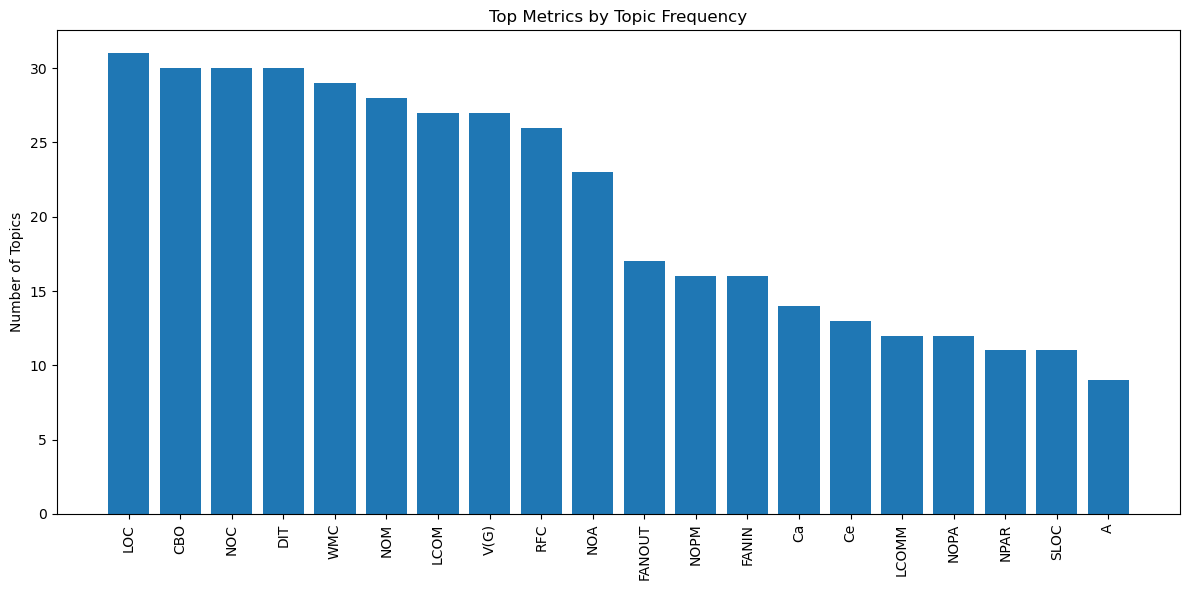

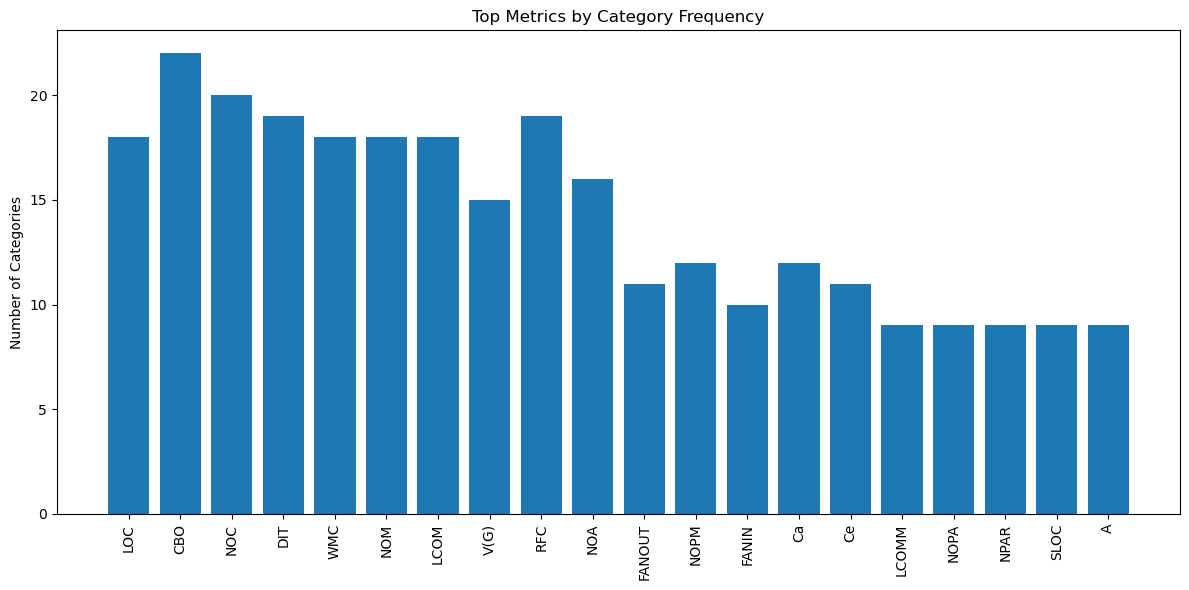

Metrics appearing in exactly one topic: 66


,Metric,Topic_Frequency,Category_Frequency,Total_Occurrences
117,AAC,1,1,1
118,AHEF,1,1,1
119,AMCoh,1,1,1
120,AMMIC,1,1,1
121,ANDC,1,1,1
...,...,...,...,...
178,SDMC,1,1,1
179,Size1,1,1,1
180,TLCOM,1,1,1
181,UWCS,1,1,1


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

csv_file = "metrics_topics.csv"

df = pd.read_csv(csv_file)

records = []

for _, row in df.iterrows():

    metrics = [
        m.strip()
        for m in str(row["Metrics"]).split(";")
        if m.strip()
    ]

    for metric in metrics:
        records.append({
            "Metric": metric,
            "Category": row["Category"],
            "Topic": row["Topic"]
        })

metric_df = pd.DataFrame(records)

metric_stats = (
    metric_df.groupby("Metric")
    .agg(
        Topic_Frequency=("Topic", "nunique"),
        Category_Frequency=("Category", "nunique"),
        Total_Occurrences=("Metric", "count")
    )
    .sort_values(
        ["Topic_Frequency",
         "Category_Frequency",
         "Total_Occurrences"],
        ascending=False
    )
    .reset_index()
)

display(metric_stats.head(25))

metric_stats.to_csv(
    "metric_summary.csv",
    index=False
)

topic_stats = (
    metric_df.groupby(["Category", "Topic"])
    .agg(
        Metric_Count=("Metric", "nunique")
    )
    .sort_values("Metric_Count", ascending=False)
)

display(topic_stats.head(20))

category_stats = (
    metric_df.groupby("Category")
    .agg(
        Topics=("Topic", "nunique"),
        Unique_Metrics=("Metric", "nunique")
    )
    .sort_values("Unique_Metrics", ascending=False)
)

display(category_stats)

plt.figure(figsize=(12, 6))

top_metrics = metric_stats.head(20)

plt.bar(
    top_metrics["Metric"],
    top_metrics["Topic_Frequency"]
)

plt.xticks(rotation=90)
plt.ylabel("Number of Topics")
plt.title("Top Metrics by Topic Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))

top_metrics = metric_stats.head(20)

plt.bar(
    top_metrics["Metric"],
    top_metrics["Category_Frequency"]
)

plt.xticks(rotation=90)
plt.ylabel("Number of Categories")
plt.title("Top Metrics by Category Frequency")
plt.tight_layout()
plt.show()

rare_metrics = metric_stats[
    metric_stats["Topic_Frequency"] == 1
]

print(
    f"Metrics appearing in exactly one topic: {len(rare_metrics)}"
)

display(
    rare_metrics.sort_values("Metric")
)

# Analysis

In [4]:
import pandas as pd


# Parameters
TOP_N = 10


# Load files
categories_df = pd.read_csv("metrics_topics.csv")
metrics_df = pd.read_csv("common_metrics.csv")


# Select top N metrics

top_metrics = (
    metrics_df
    .sort_values("Usages", ascending=False)
    .head(TOP_N)["Acronym"]
    .tolist()
)

print("Selected metrics:")
print(top_metrics)


# Build category-metric matrix

categories = categories_df["Category"].unique()

matrix = pd.DataFrame(
    0,
    index=categories,
    columns=top_metrics
)

for category in categories:
    # Collect all metrics appearing in this category
    category_metrics = set()

    rows = categories_df[categories_df["Category"] == category]

    for metrics_str in rows["Metrics"]:
        metrics = [m.strip() for m in str(metrics_str).split(";")]
        category_metrics.update(metrics)

    # Mark presence of top metrics
    for metric in top_metrics:
        if metric in category_metrics:
            matrix.loc[category, metric] = 1


# Display result

display(matrix)

# Optional: save
matrix.to_csv("category_metric_matrix.csv")

print("\n" + "="*80)
print("Selected Metrics by Category")
print("="*80)

for category in matrix.index:

    selected = [
        metric
        for metric in top_metrics
        if matrix.loc[category, metric] == 1
    ]

    if selected:  # only categories with at least one selected metric
        print(f"\n{category} ({len(selected)} metrics)")
        print(", ".join(selected))

Selected metrics:
['WMC', 'CBO', 'LCOM', 'DIT', 'LOC', 'NOC', 'RFC', 'NOM', 'V(G)', 'NOA']


,WMC,CBO,LCOM,DIT,LOC,NOC,RFC,NOM,V(G),NOA
Failures,1,1,1,1,1,1,1,1,1,1
Quality,1,1,1,1,1,1,1,1,1,1
Complexity,1,1,1,1,1,1,1,1,1,1
Assessment,1,1,1,1,1,1,1,1,1,1
Change,1,1,1,1,1,1,1,1,1,1
Cohesion,0,1,1,0,0,0,0,0,0,0
Other,1,1,1,1,1,1,1,1,1,1
Testing,1,1,1,1,1,1,1,1,1,1
Maintainability,1,1,1,1,1,1,1,1,1,0
Refactoring,1,1,1,1,1,1,1,1,1,1



Selected Metrics by Category

Failures (10 metrics)
WMC, CBO, LCOM, DIT, LOC, NOC, RFC, NOM, V(G), NOA

Quality (10 metrics)
WMC, CBO, LCOM, DIT, LOC, NOC, RFC, NOM, V(G), NOA

Complexity (10 metrics)
WMC, CBO, LCOM, DIT, LOC, NOC, RFC, NOM, V(G), NOA

Assessment (10 metrics)
WMC, CBO, LCOM, DIT, LOC, NOC, RFC, NOM, V(G), NOA

Change (10 metrics)
WMC, CBO, LCOM, DIT, LOC, NOC, RFC, NOM, V(G), NOA

Cohesion (2 metrics)
CBO, LCOM

Other (10 metrics)
WMC, CBO, LCOM, DIT, LOC, NOC, RFC, NOM, V(G), NOA

Testing (10 metrics)
WMC, CBO, LCOM, DIT, LOC, NOC, RFC, NOM, V(G), NOA

Maintainability (9 metrics)
WMC, CBO, LCOM, DIT, LOC, NOC, RFC, NOM, V(G)

Refactoring (10 metrics)
WMC, CBO, LCOM, DIT, LOC, NOC, RFC, NOM, V(G), NOA

Thresholds (10 metrics)
WMC, CBO, LCOM, DIT, LOC, NOC, RFC, NOM, V(G), NOA

Performance (9 metrics)
WMC, CBO, DIT, LOC, NOC, RFC, NOM, V(G), NOA

Reliability (9 metrics)
WMC, CBO, LCOM, DIT, LOC, NOC, RFC, NOM, V(G)

Tools (10 metrics)
WMC, CBO, LCOM, DIT, LOC, NOC, RFC